# Onderzoeksvragen


## data laden en preprocessen





In [1]:
import pandas as pd
import networkx as nx
import re
from collections import Counter
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [2]:
%%time
df= pd.read_csv('LidoLinks.csv.gz', header=None)
print(df.shape)
df.head()


(7355861, 2)
CPU times: total: 11 s
Wall time: 11 s


,0,1
0,jurisprudentie/id/ECLI:NL:RBAMS:2015:6776,bwb/id/BWBR0001854/2967974/1984-05-01/1984-05-01
1,jurisprudentie/id/ECLI:NL:RBOBR:2018:4470,bwb/id/BWBR0005290/2913524/2018-07-28/2018-07-28
2,jurisprudentie/id/ECLI:NL:RBAMS:2019:4496,bwb/id/BWBR0001854/2963144/1986-05-19/1986-05-19
3,jurisprudentie/id/ECLI:NL:RBOVE:2024:2366,bwb/id/BWBR0001827/3178144/2002-01-01/2002-01-01
4,jurisprudentie/id/ECLI:NL:RBUTR:2006:BA7009,bwb/id/BWBR0002375/2060994/2006-01-01/2006-01-01


In [3]:
%%time
# haal de datums van de id's af. Dit werkt alleen op de bwb/id knopen
df[1]=df[1].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 
df[0]=df[0].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 

CPU times: total: 25.4 s
Wall time: 25.9 s


In [4]:
df['groep_s'] = df[0].str.replace(r'/id.*', r'', regex=True)
df['groep_t'] = df[1].str.replace(r'/id.*', r'', regex=True)

## 11. Onderzoeksvraag

**Hoofdvraag:** Welke structurele eigenschappen vertoont het Nederlandse jurisprudentie-citatienetwerk van Rechtspraak.nl, en hoe is juridische invloed binnen dit netwerk verdeeld over uitspraken, rechtsgebieden en rechterlijke instanties?

**DV1** Hoe valt de jurisprudentie-subgraaf uiteen in componenten, in hoeverre vertoont deze een bow-tie-structuur vergelijkbaar met die van het WWW (Broder et al., 2000), en welke dichte kernstructuren worden zichtbaar via k-core-analyse?

**DV2** Hoe is invloed verdeeld over uitspraken volgens in-degree, PageRank en HITS-authority, en in hoeverre vertonen deze verdelingen een power-law?

**DV3** In welke mate identificeren in-degree, PageRank en HITS-authority dezelfde uitspraken als invloedrijk, en zijn er systematische verschillen?

**DV4** Welke communities ontstaan via Leiden-detectie (Traag, Waltman & Van Eck, 2019) op de jurisprudentie-subgraaf, en in hoeverre vallen deze samen met de rechtsgebieden?

**DV5**  In welke mate komen citaties uit lagere instanties (rechtbank, kantongerecht) terecht bij hogere instanties (gerechtshof, Hoge Raad, Raad van State, CRvB, CBb), en wat zegt de assortativity over de hiërarchische structuur van het netwerk?

In [8]:
# G_jur: citatienetwerk (jurisprudentie -> jurisprudentie)
mask_jur = (df['groep_s'] == 'jurisprudentie') & (df['groep_t'] == 'jurisprudentie')
df_jur = df.loc[mask_jur, [0, 1]].copy()

# selfloops weghalen
self_loops = (df_jur[0] == df_jur[1]).sum()
df_jur = df_jur[df_jur[0] != df_jur[1]]

# dubbele edghes weghalen
n_before_dedup = len(df_jur)
df_jur = df_jur.drop_duplicates()
n_after_dedup = len(df_jur)

G_jur = nx.from_pandas_edgelist(df_jur, source=0, target=1, create_using=nx.DiGraph())

print('Citatienetwerk jur->jur:')
print(f'nodes:{G_jur.number_of_nodes():,}')
print(f'edges{G_jur.number_of_edges():,}')
print(f'zelfreferenties verwijderd:{self_loops:,}')
print(f'dubbele edges verwijderd:{n_before_dedup - n_after_dedup:,}')
print(f'dichtheid:{nx.density(G_jur):.2e}')


Citatienetwerk jur->jur:
nodes:674,589
edges1,353,664
zelfreferenties verwijderd:9
dubbele edges verwijderd:0
dichtheid:2.97e-06


## DV1  Macrostructuur van het netwerk

1. Componenten (WCC en SCC)
2. ow-tie decompositie (Broder et al., 2000)
3. k-core decompositie (Seidman, 1983)

In [9]:
wccs = list(nx.weakly_connected_components(G_jur))
wcc_sizes = sorted([len(c) for c in wccs], reverse=True)

print(f'aantal WCCs:       {len(wccs):,}')
print(f'grootste WCC:      {wcc_sizes[0]:,} knopen ({wcc_sizes[0]/G_jur.number_of_nodes()*100:.2f}%)')
print(f'2e grootste WCC:   {wcc_sizes[1] if len(wcc_sizes) > 1 else 0:,}')
print(f'aantal singletons: {sum(1 for s in wcc_sizes if s == 1):,}')

aantal WCCs:       67,837
grootste WCC:      526,576 knopen (78.06%)
2e grootste WCC:   33
aantal singletons: 0


In [24]:
def bowtie_decomposition(G):

    # grootste zwakke component
    largest_wcc = max(nx.weakly_connected_components(G), key=len)
    Gw = G.subgraph(largest_wcc)

    # grootste sterke component binnen de grootste WCC
    largest_scc_in_wcc = max(nx.strongly_connected_components(Gw), key=len)
    scc_node = next(iter(largest_scc_in_wcc))

In [23]:
# k-core op ongerichte netwerk
G_jur_undirected = G_jur.to_undirected()

core_numbers = nx.core_number(G_jur_undirected)
print(f'maximale k-core: k = {max(core_numbers.values())}')

maximale k-core: k = 19


## DV2 Verdeling van invloed

Drie maten naast elkaar: in-degree, PageRank, HITS-authority. Voor elke maat: verdeling, ongelijkheid (Gini), concentratie aan de top, en power-law-fit volgens Clauset, Shalizi en Newman (2009).

In [11]:
# in-degree
in_degree = dict(G_jur.in_degree())

# PageRank
pagerank = nx.pagerank(G_jur, alpha=0.85)

# HITS
hubs, authorities = nx.hits(G_jur, max_iter=200, tol=1e-6)

In [12]:
df_scores = pd.DataFrame({
    'ecli': list(G_jur.nodes()),
})
df_scores['in_degree'] = df_scores['ecli'].map(in_degree)
df_scores['pagerank'] = df_scores['ecli'].map(pagerank)
df_scores['authority'] = df_scores['ecli'].map(authorities)
print(df_scores.shape)
df_scores.describe()

(674589, 4)


,in_degree,pagerank,authority
count,674589.000000,6.745890e+05,6.745890e+05
mean,2.006650,1.482384e-06,1.482384e-06
std,33.048509,1.260278e-05,2.733803e-04
min,0.000000,5.987837e-07,-4.333344e-18
25%,0.000000,5.987837e-07,0.000000e+00
50%,1.000000,8.106188e-07,1.198212e-20
75%,1.000000,1.559940e-06,1.510269e-09
max,21160.000000,7.226992e-03,2.235883e-01


## ongelijkheid en concentratie

In [16]:
# Gini-coef (0 = volledig gelijk, 1 = volledig ongelijk)
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    if x.sum() == 0:
        return 0
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x)) / (n * x.sum()) - (n + 1) / n

def top_k_share(x, k_frac):
    x = np.sort(np.asarray(x, dtype=float))[::-1]
    k = max(1, int(np.ceil(len(x) * k_frac)))
    return x[:k].sum() / x.sum() if x.sum() > 0 else 0.0


rows = []

for col in ['in_degree', 'pagerank', 'authority']:
    x = df_scores[col].values
    rows.append({
        'maat': col,
        'Gini': gini(x),
        'top-1%': top_k_share(x, 0.01),
        'top-5%': top_k_share(x, 0.05),
        'top-10%': top_k_share(x, 0.10)
    })

summary = pd.DataFrame(rows)

summary[['Gini', 'top-1%', 'top-5%', 'top-10%']] = summary[
    ['Gini', 'top-1%', 'top-5%', 'top-10%']
].round(3)

summary



,maat,Gini,top-1%,top-5%,top-10%
0,in_degree,0.759,0.371,0.573,0.670
1,pagerank,0.457,0.195,0.314,0.394
2,authority,0.977,0.661,0.984,0.997


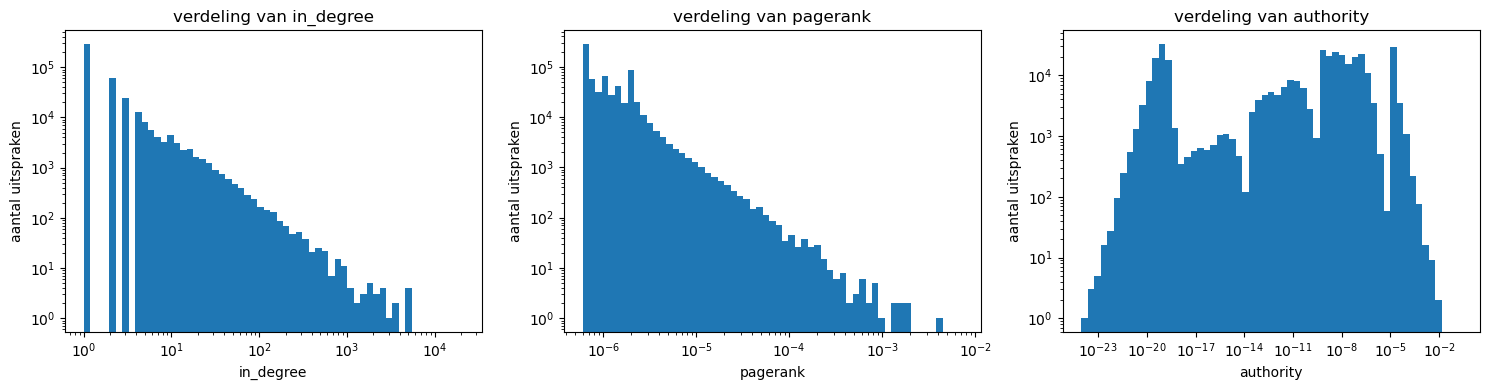

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols = ['in_degree', 'pagerank', 'authority']

for ax, col in zip(axes, cols):
    vals = df_scores[col].values
    vals = vals[vals > 0]

    ax.hist(vals, bins=np.logspace(np.log10(vals.min()),
                                   np.log10(vals.max()), 60))

    ax.set(xscale='log',
           yscale='log',
           xlabel=col,
           ylabel='aantal uitspraken',
           title=f'verdeling van {col}')

plt.tight_layout()
plt.show()

Verdeling in-degree:
De verdeling van het in-degree volgt een power-law verdeling. ''survival of the fittest'', een klein aantal uitspraken wordt heel vaak geciteerd

Verdeling pagerank: Deze laat ook een power-law patroon zien

Verdeling van authority: Deze wijkt opvallend af van de andere twee en heeft meerder pieken. 

## powerlaw fits

In [22]:
import powerlaw
import warnings
warnings.filterwarnings('ignore')
